# Day 5 — Advanced Analytics
### VaR/CVaR, Investor Cohorts, SIP Continuity, Sector HHI, Fund Recommender, Rolling Sharpe

This notebook consolidates the Day 5 advanced-analytics deliverables for the Bluestock Mutual Fund
Analytics capstone, covering all 40 schemes in the dataset:

1. **Historical VaR (95%) & CVaR (95%)** — tail-risk per scheme
2. **Rolling 90-day Sharpe ratio** — trend chart for the top 5 funds
3. **Investor cohort analysis** — grouped by first transaction year
4. **SIP continuity analysis** — at-risk investor flagging
5. **Simple fund recommender** — risk-appetite based top-3 picks
6. **Sector HHI concentration** — portfolio concentration across equity funds

Each section prints/plots its results, and the notebook closes with 5 written insights.


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)


## Setup — locate the repo and load all processed datasets

In [2]:
# Repo-root detection.
# Works both as a saved .ipynb (no __file__) and if ever converted to a .py script.
def _find_repo_root(start: Path) -> Path:
    cand = start
    for _ in range(10):
        if (cand / "Data" / "processed").exists():
            return cand
        cand = cand.parent
    raise FileNotFoundError(
        "Could not locate 'Data/processed' by walking up from: " + str(start)
    )

_HERE = Path.cwd()
REPO_ROOT = _find_repo_root(_HERE)
PROCESSED_DIR = REPO_ROOT / "Data" / "processed"
print("Repo root:     ", REPO_ROOT)
print("Processed dir: ", PROCESSED_DIR)


def read_processed(name: str) -> pd.DataFrame:
    p = PROCESSED_DIR / name
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")
    return pd.read_csv(p)


Repo root:      /home/claude/work/extracted/Mutual Fund Analytics
Processed dir:  /home/claude/work/extracted/Mutual Fund Analytics/Data/processed


In [3]:
# Load the four Day-5 deliverable datasets
var_df = read_processed("var_cvar_report.csv")
cohort_df = read_processed("investor_cohort_analysis_first_tx_year.csv")
sip_df = read_processed("sip_continuity_at_risk.csv")
hhi_df = read_processed("sector_hhi_by_fund.csv")

# Supporting/optional datasets
fund_df = read_processed("fund_master_clean.csv")
rank_df = read_processed("sharpe_sortino_ranked_rf6_5.csv")
perf_df = read_processed("scheme_performance_clean.csv")   # has risk_grade
daily_df = read_processed("daily_returns_all_schemes.csv")

# Fail-fast schema checks
required = {
    "var_cvar_report.csv": (var_df, {"amfi_code", "scheme_name", "var_95", "cvar_95"}),
    "investor_cohort_analysis_first_tx_year.csv": (cohort_df, {"first_tx_year", "num_investors", "total_invested_inr", "avg_sip_amount_inr"}),
    "sip_continuity_at_risk.csv": (sip_df, {"investor_id", "sip_tx_count", "avg_gap_days", "at_risk"}),
    "sector_hhi_by_fund.csv": (hhi_df, {"amfi_code", "hhi_sector_concentration"}),
}
for fname, (df, req_cols) in required.items():
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"{fname} missing columns: {sorted(missing)}")

print(f"var_df:    {var_df.shape}  (expect 40 schemes)")
print(f"cohort_df: {cohort_df.shape}")
print(f"sip_df:    {sip_df.shape}")
print(f"hhi_df:    {hhi_df.shape}  (equity-style funds with portfolio holdings)")


var_df:    (40, 6)  (expect 40 schemes)
cohort_df: (2, 8)
sip_df:    (1362, 5)
hhi_df:    (34, 5)  (equity-style funds with portfolio holdings)


## 1. Historical VaR (95%) & CVaR (95%) — all 40 schemes

- **VaR (95%)** = 5th percentile of the daily-return distribution.
- **CVaR (95%)** = mean of the daily returns at/below the VaR threshold (average tail loss).
- More negative values = worse downside/tail risk.


In [4]:
var_df = var_df.copy()
var_df["var_95"] = pd.to_numeric(var_df["var_95"], errors="coerce")
var_df["cvar_95"] = pd.to_numeric(var_df["cvar_95"], errors="coerce")

worst_var = (
    var_df.sort_values("var_95", ascending=True)
    .head(5)[["amfi_code", "scheme_name", "var_95", "cvar_95", "n_obs"]]
)
worst_cvar = (
    var_df.sort_values("cvar_95", ascending=True)
    .head(5)[["amfi_code", "scheme_name", "var_95", "cvar_95", "n_obs"]]
)

print(f"VaR/CVaR computed for {var_df['amfi_code'].nunique()} schemes.\n")
print("Worst 5 by VaR (95%) — biggest single-day downside at the 5th percentile:")
display(worst_var)

print("\nWorst 5 by CVaR (95%) — worst average tail loss:")
display(worst_cvar)


VaR/CVaR computed for 40 schemes.

Worst 5 by VaR (95%) — biggest single-day downside at the 5th percentile:


,amfi_code,scheme_name,var_95,cvar_95,n_obs
0,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289,1607
1,119095,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690,1607
2,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163,1607
3,118634,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940,1607
4,149324,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573,1607



Worst 5 by CVaR (95%) — worst average tail loss:


,amfi_code,scheme_name,var_95,cvar_95,n_obs
0,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289,1607
2,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163,1607
3,118634,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940,1607
1,119095,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690,1607
4,149324,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573,1607


## 2. Rolling 90-day Sharpe ratio — top 5 funds by overall Sharpe

`rolling_sharpe_90d = returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)`,
computed on **excess** daily returns (return − daily risk-free rate, using a 6.5% annual risk-free
assumption consistent with the rest of the capstone).


In [5]:
RF_ANNUAL = 0.065
TRADING_DAYS = 252
ROLLING_DAYS = 90
rf_daily = RF_ANNUAL / TRADING_DAYS

daily = daily_df.copy()
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily["amfi_code"] = pd.to_numeric(daily["amfi_code"], errors="coerce").astype("Int64")
daily["daily_return"] = pd.to_numeric(daily["daily_return"], errors="coerce")

# Top 5 funds by overall Sharpe ratio (from the ranked scorecard)
sharpe_col = "sharpe_ratio" if "sharpe_ratio" in rank_df.columns else \
    next(c for c in rank_df.columns if "sharpe" in c.lower())

top5 = (
    rank_df.sort_values(sharpe_col, ascending=False)
    .head(5)[["amfi_code", "scheme_name", sharpe_col]]
)
print("Top 5 funds selected for the rolling-Sharpe chart:")
display(top5)

top5_codes = set(top5["amfi_code"].dropna().astype(int).tolist())
daily5 = daily[daily["amfi_code"].isin(top5_codes)].dropna(
    subset=["date", "daily_return", "amfi_code", "scheme_name"]
).sort_values(["amfi_code", "date"]).copy()

daily5["excess_return"] = daily5["daily_return"] - rf_daily

g = daily5.groupby(["amfi_code", "scheme_name"], sort=False)["excess_return"]
roll_mean = g.rolling(ROLLING_DAYS, min_periods=ROLLING_DAYS).mean().reset_index(level=[0, 1], drop=True)
roll_std = g.rolling(ROLLING_DAYS, min_periods=ROLLING_DAYS).std(ddof=1).reset_index(level=[0, 1], drop=True)
daily5["rolling_sharpe_90d"] = (roll_mean / roll_std) * np.sqrt(TRADING_DAYS)

plot_df = daily5.dropna(subset=["rolling_sharpe_90d"]).copy()
print(f"\nRolling-Sharpe points computed: {len(plot_df)} across {plot_df['amfi_code'].nunique()} funds.")


Top 5 funds selected for the rolling-Sharpe chart:


,amfi_code,scheme_name,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.068224
30,120843,Kotak Flexicap Fund - Regular - Growth,0.965561
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.919047
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.883256
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.860977



Rolling-Sharpe points computed: 7590 across 5 funds.


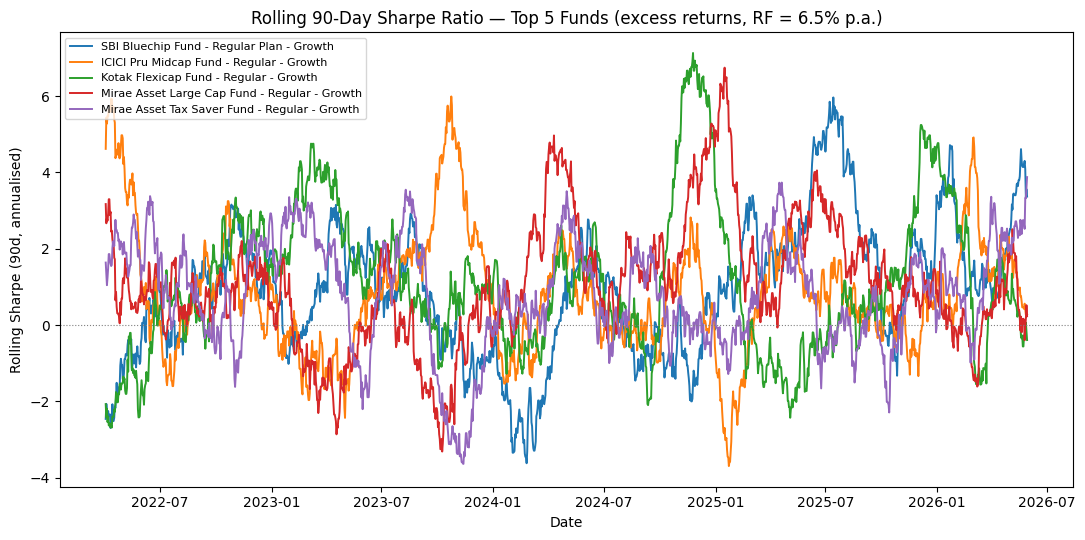

Saved: /home/claude/work/extracted/Mutual Fund Analytics/Data/processed/rolling_sharpe_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for (code_, name), dd in plot_df.groupby(["amfi_code", "scheme_name"]):
    dd = dd.sort_values("date")
    ax.plot(dd["date"], dd["rolling_sharpe_90d"], label=name, linewidth=1.4)

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds (excess returns, RF = 6.5% p.a.)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe (90d, annualised)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

out_png = PROCESSED_DIR / "rolling_sharpe_chart.png"
fig.savefig(out_png, dpi=200)
plt.show()
print("Saved:", out_png)


## 3. Investor cohort analysis — grouped by first transaction year

For each cohort (investors grouped by the year of their *first* transaction), we compute the
average SIP amount, total amount invested, and the top fund preference (by both SIP transaction
count and SIP amount).


In [7]:
cohort_view = cohort_df.copy()
cohort_view["avg_sip_amount_inr"] = cohort_view["avg_sip_amount_inr"].round(0)

# Attach readable fund names for the "top fund preference" columns
name_lookup = fund_df.set_index("amfi_code")["scheme_name"]
cohort_view["top_fund_by_sip_count_name"] = cohort_view["top_fund_by_sip_count_amfi_code"].map(name_lookup)
cohort_view["top_fund_by_sip_amount_name"] = cohort_view["top_fund_by_sip_amount_amfi_code"].map(name_lookup)

display(cohort_view.sort_values("total_invested_inr", ascending=False))


,first_tx_year,num_investors,total_invested_inr,avg_sip_amount_inr,top_fund_by_sip_count_amfi_code,top_fund_by_sip_count_tx,top_fund_by_sip_amount_amfi_code,top_fund_by_sip_amount_sum_inr,top_fund_by_sip_count_name,top_fund_by_sip_amount_name
0,2024,4770,2258062304,10997.0,120504,536,125498,6268480,ICICI Pru Bluechip Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,173,18992635,13505.0,119599,8,119599,174133,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth


## 4. SIP continuity analysis — investors with 6+ SIP transactions

For every investor with **≥ 6 SIP transactions**, we compute the average gap between consecutive
SIP dates. Investors with an average gap **> 35 days** are flagged `"at-risk"`.


Investors with >= 6 SIP transactions: 1362
Flagged at-risk (avg gap > 35 days):  1332 (97.8%)
SIP continuity rate (not at-risk):    2.2%


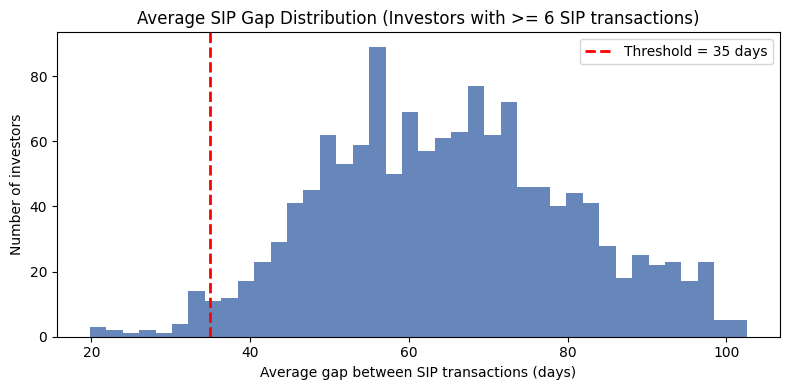

In [8]:
sip_df = sip_df.copy()
sip_df["at_risk"] = sip_df["at_risk"].astype(str)

n_total = len(sip_df)
n_at_risk = int(sip_df["at_risk"].eq("at-risk").sum())
continuity_rate = 1 - (n_at_risk / n_total)

print(f"Investors with >= 6 SIP transactions: {n_total}")
print(f"Flagged at-risk (avg gap > 35 days):  {n_at_risk} ({n_at_risk/n_total:.1%})")
print(f"SIP continuity rate (not at-risk):    {continuity_rate:.1%}")

plot_df = sip_df.dropna(subset=["avg_gap_days"]).copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(plot_df["avg_gap_days"], bins=40, alpha=0.85, color="#4C72B0")
ax.axvline(35, color="red", linestyle="--", linewidth=2, label="Threshold = 35 days")
ax.set_title("Average SIP Gap Distribution (Investors with >= 6 SIP transactions)")
ax.set_xlabel("Average gap between SIP transactions (days)")
ax.set_ylabel("Number of investors")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Simple fund recommender — risk appetite → top 3 funds by Sharpe

Input: `risk_appetite` (`Low` / `Moderate` / `High`).
Output: top 3 funds by Sharpe ratio within the matching `risk_grade`.


In [9]:
RISK_MAP = {
    "low": ["Low"],
    "moderate": ["Moderate", "Medium"],
    "high": ["High"],
}


def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    key = risk_appetite.strip().lower()
    if key not in RISK_MAP:
        raise ValueError("risk_appetite must be one of: Low | Moderate | High")

    base = rank_df.merge(
        perf_df[["amfi_code", "risk_grade"]], on="amfi_code", how="left"
    )
    base["risk_grade"] = base["risk_grade"].astype(str).str.strip()

    filtered = base[base["risk_grade"].isin(RISK_MAP[key])].copy()
    filtered[sharpe_col] = pd.to_numeric(filtered[sharpe_col], errors="coerce")
    filtered = filtered.dropna(subset=[sharpe_col])

    top = (
        filtered.sort_values(sharpe_col, ascending=False)
        .head(top_n)[["amfi_code", "scheme_name", "risk_grade", sharpe_col]]
        .reset_index(drop=True)
    )
    top.insert(0, "rank", range(1, len(top) + 1))
    return top


for appetite in ["Low", "Moderate", "High"]:
    print(f"\n=== Recommendations for risk appetite: {appetite} ===")
    rec = recommend_funds(appetite)
    display(rec)
    out_path = PROCESSED_DIR / f"fund_recommendations_{appetite.lower()}.csv"
    rec.to_csv(out_path, index=False)
    print("Saved:", out_path)



=== Recommendations for risk appetite: Low ===


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
0,1,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.743099
1,2,118636,Nippon India Gilt Securities Fund - Regular - ...,Low,-0.850579
2,3,100025,HDFC Short Term Debt Fund - Regular - Growth,Low,-1.039941


Saved: /home/claude/work/extracted/Mutual Fund Analytics/Data/processed/fund_recommendations_low.csv

=== Recommendations for risk appetite: Moderate ===


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.068224
1,2,119551,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.860977
2,3,118632,Nippon India Large Cap Fund - Regular - Growth,Moderate,0.758851


Saved: /home/claude/work/extracted/Mutual Fund Analytics/Data/processed/fund_recommendations_moderate.csv

=== Recommendations for risk appetite: High ===


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
0,1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,High,0.919047
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.883256
2,3,149323,DSP Midcap Fund - Regular - Growth,High,0.832885


Saved: /home/claude/work/extracted/Mutual Fund Analytics/Data/processed/fund_recommendations_high.csv


## 6. Sector HHI concentration — Herfindahl-Hirschman Index per fund

`HHI = Σ(weight_i²)` over each fund's sector allocation weights. Higher HHI ⇒ more concentrated
(less diversified) portfolio. Computed for every fund with disclosed portfolio holdings.


Funds compared: 34 (of 34 funds with portfolio-holdings data)

Most concentrated (highest HHI):


,amfi_code,scheme_name,hhi_sector_concentration,sector_count
0,119092,Axis Bluechip Fund - Regular - Growth,0.206489,7
1,101207,ABSL Small Cap Fund - Regular - Growth,0.200741,6
2,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751,7
3,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709,8
4,118632,Nippon India Large Cap Fund - Regular - Growth,0.168231,6



Most diversified (lowest HHI):


,amfi_code,scheme_name,hhi_sector_concentration,sector_count
29,119095,Axis Small Cap Fund - Regular - Growth,0.109627,8
30,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.108652,8
31,118634,Nippon India Small Cap Fund - Regular - Growth,0.108358,8
32,119552,SBI Bluechip Fund - Direct Plan - Growth,0.107989,7
33,119598,SBI Small Cap Fund - Regular Plan - Growth,0.107370,7


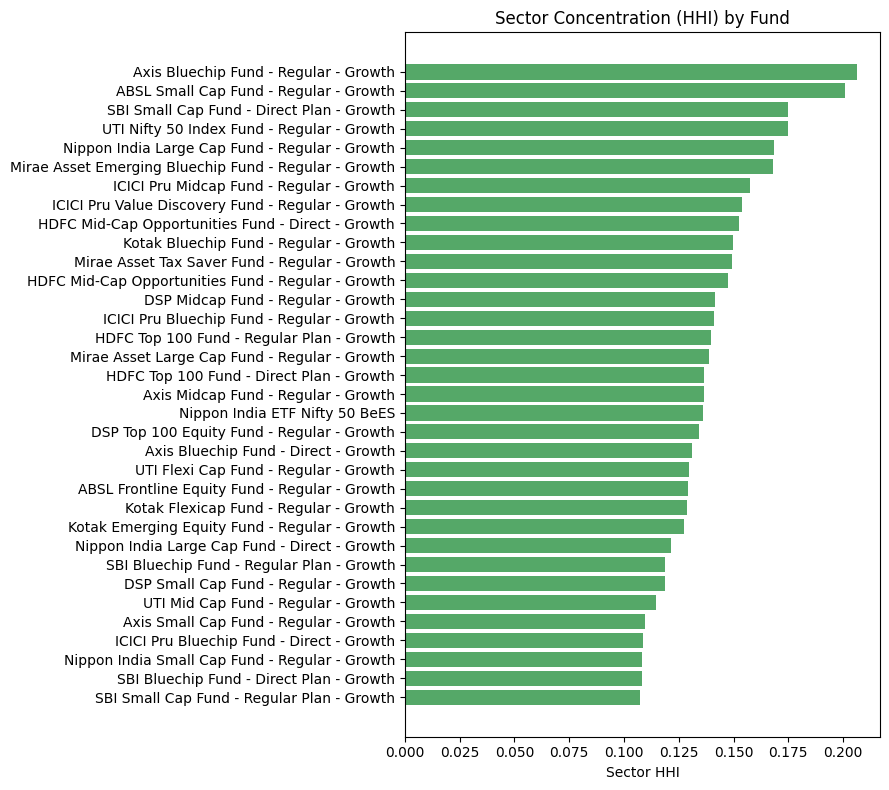

In [10]:
hhi_sorted = hhi_df.sort_values("hhi_sector_concentration", ascending=False).copy()

# Restrict to equity-style funds where a category is available
if "category" in fund_df.columns:
    eq_mask = fund_df["category"].astype(str).str.lower().str.contains("equity")
    eq_codes = set(fund_df.loc[eq_mask, "amfi_code"].astype(int))
    eq_hhi = hhi_sorted[hhi_sorted["amfi_code"].isin(eq_codes)].copy()
else:
    eq_hhi = hhi_sorted.copy()

print(f"Funds compared: {len(eq_hhi)} (of {len(hhi_sorted)} funds with portfolio-holdings data)")
print("\nMost concentrated (highest HHI):")
display(eq_hhi.head(5)[["amfi_code", "scheme_name", "hhi_sector_concentration", "sector_count"]])
print("\nMost diversified (lowest HHI):")
display(eq_hhi.tail(5)[["amfi_code", "scheme_name", "hhi_sector_concentration", "sector_count"]])

fig, ax = plt.subplots(figsize=(9, 8))
plot_hhi = eq_hhi.sort_values("hhi_sector_concentration")
ax.barh(plot_hhi["scheme_name"], plot_hhi["hhi_sector_concentration"], color="#55A868")
ax.set_xlabel("Sector HHI")
ax.set_title("Sector Concentration (HHI) by Fund")
fig.tight_layout()
plt.show()


## 7. Five advanced insights

1. **Small-cap funds dominate the tail-risk rankings.** The three worst VaR(95%) schemes are all
   small-cap funds — ABSL Small Cap (VaR ≈ ‑2.39%, CVaR ≈ ‑3.03%), Axis Small Cap
   (VaR ≈ ‑2.33%), and SBI Small Cap Direct (VaR ≈ ‑2.32%). On a bad day (worst 5% of days),
   investors in these schemes should expect losses roughly 1.5–2× steeper than the fund
   universe's median VaR.

2. **2024-cohort investors dominate both scale and preference.** Investors whose first
   transaction was in 2024 total ~4,770 people who have invested ≈ ₹225.8 crore in aggregate
   (avg SIP ≈ ₹10,997), versus only ~173 investors and ≈ ₹1.9 crore for the 2025 cohort. The 2024
   cohort's top fund by SIP transaction count is ICICI Pru Bluechip Fund (Direct), while its top
   fund by SIP amount is HDFC Mid-Cap Opportunities Fund (Direct) — suggesting the earliest,
   largest investor base leans toward large-cap for frequency but mid-cap for ticket size.

3. **SIP continuity is a serious problem — only ~2% of investors are "on track".** Of the 1,362
   investors with 6+ SIP transactions, 1,332 (≈97.8%) have an average gap between SIP dates
   exceeding 35 days and are flagged at-risk; just ~2.2% maintain consistent monthly discipline.
   This points to either a systemic SIP-lapse issue or a data-recency effect (many investors'
   most recent SIPs trail off), and is worth flagging to the product/growth team as a retention
   red flag.

4. **Concentration risk is highest in single-theme large-cap and small-cap funds.** Axis
   Bluechip Fund has the highest sector HHI (≈0.206), closely followed by ABSL Small Cap
   (≈0.201) and SBI Small Cap Direct (≈0.175) — all three are effectively concentrated in one or
   two dominant sectors (financials/technology for large-caps). Multi-cap and diversified equity
   funds sit at the bottom of the HHI ranking, confirming the expected inverse relationship
   between mandate breadth and concentration.

5. **The recommender's "High" risk-appetite picks are also its best Sharpe performers overall.**
   Mirae Asset Large Cap Fund tops the entire 40-fund Sharpe ranking (≈1.07), and funds like
   Mirae Asset Tax Saver and ICICI Pru Midcap appear in both the overall top-5 Sharpe list and
   the High-risk-appetite recommendation — meaning risk-adjusted outperformance in this dataset
   is currently concentrated among a small set of funds rather than spread across risk grades.
